In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Estimate π with Monte Carlo

The idea is simple: inscribe a circle of radius 1 inside a 2×2 square. If you throw random darts uniformly at the square, the fraction that land inside the circle should approximate π/4.

1. Generate **N = 100,000** random (x, y) points where x and y are each drawn from Uniform(−1, 1).
2. Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
3. Estimate π as `4 × (points inside) / N`.
4. Print your estimate alongside the true value of π.
5. Create a scatter plot of the first **5,000** points, coloring inside points differently from outside points. Draw the unit circle on top for reference.

**Convergence plot:** Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.

**Guiding question:** At roughly what sample size does your estimate stabilize within ±0.01 of true π?


Estimated pi: 3.144120
True pi:      3.141593
Absolute error: 0.002527


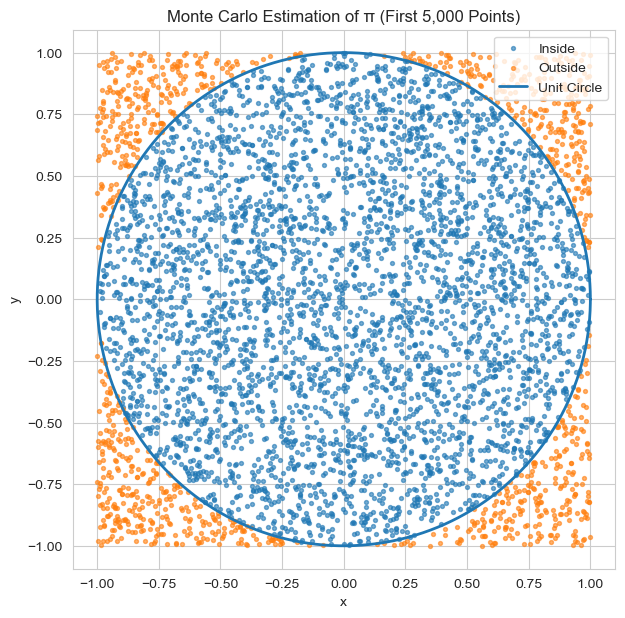

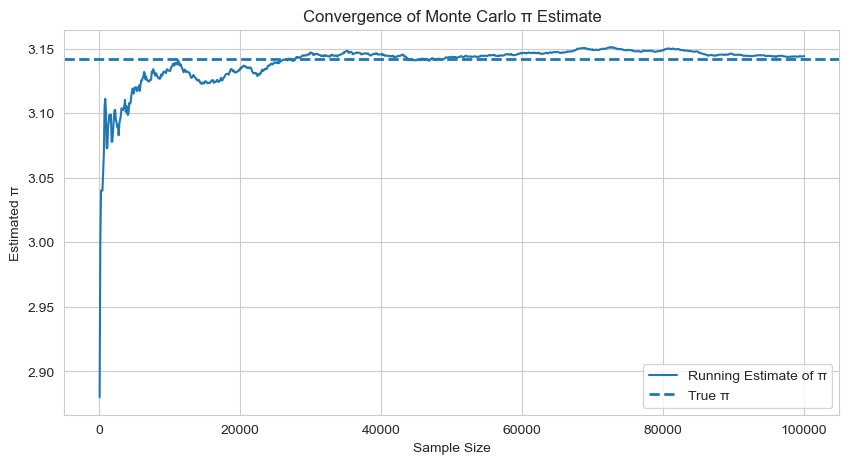

First sample size within ±0.01 of true π: 6400


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# 1. Generate N random points
N = 100_000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# 2. Classify points
inside = x**2 + y**2 <= 1

# 3. Estimate pi
pi_estimate = 4 * inside.mean()

# 4. Print estimate and true pi
print(f"Estimated pi: {pi_estimate:.6f}")
print(f"True pi:      {np.pi:.6f}")
print(f"Absolute error: {abs(pi_estimate - np.pi):.6f}")

# 5. Scatter plot of first 5,000 points
n_plot = 5000
x_plot = x[:n_plot]
y_plot = y[:n_plot]
inside_plot = inside[:n_plot]

theta = np.linspace(0, 2 * np.pi, 400)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

plt.figure(figsize=(7, 7))
plt.scatter(x_plot[inside_plot], y_plot[inside_plot], s=8, alpha=0.6, label="Inside")
plt.scatter(x_plot[~inside_plot], y_plot[~inside_plot], s=8, alpha=0.6, label="Outside")
plt.plot(circle_x, circle_y, linewidth=2, label="Unit Circle")
plt.title("Monte Carlo Estimation of π (First 5,000 Points)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

# Convergence plot: running estimate every 100 points
step = 100
sample_sizes = np.arange(step, N + 1, step)
running_estimates = [
    4 * inside[:n].mean() for n iburadaki 100 her 100 sn sample_sizes
]

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, running_estimates, label="Running Estimate of π")
plt.axhline(np.pi, linestyle="--", linewidth=2, label="True π")
plt.title("Convergence of Monte Carlo π Estimate")
plt.xlabel("Sample Size")
plt.ylabel("Estimated π")
plt.legend()
plt.show()

# Guiding question:
# first sample size where estimate is within ±0.01 of true pi
tolerance = 0.01
stable_indices = np.where(np.abs(np.array(running_estimates) - np.pi) <= tolerance)[0]

if len(stable_indices) > 0:
    first_stable_n = sample_sizes[stable_indices[0]]
    print(f"First sample size within ±0.01 of true π: {first_stable_n}")
else:
    print("The estimate did not get within ±0.01 in this run.")

### Task 2: Coin Flips and Empirical Probability

Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

1. Simulate **10,000** fair coin flips (use `np.random.choice([0, 1])` or `np.random.binomial(1, 0.5, size=10000)`).
2. Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).
3. Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.
4. Repeat the experiment **5 times** (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.

**Guiding question:** How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?

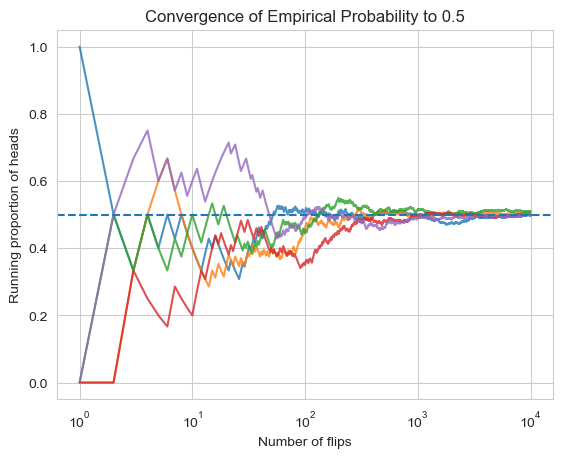

Around 2,000–3,000 flips


In [4]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000

for i in range(5):
    flips = np.random.binomial(1, 0.5, size=n)
    running_prop = np.cumsum(flips) / np.arange(1, n + 1)
    plt.plot(np.arange(1, n + 1), running_prop, alpha=0.8)

plt.axhline(0.5, linestyle='--')
plt.xscale('log')
plt.xlabel('Number of flips')
plt.ylabel('Running proportion of heads')
plt.title('Convergence of Empirical Probability to 0.5')
plt.show()
print('Around 2,000–3,000 flips')

### Task 3: Simulating Binomial Experiments

A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

1. Simulate **10,000 batches** of 50 widgets each, where each widget has a 3% chance of being defective.
2. For each batch, record the number of defective widgets found.
3. Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
4. From your simulation, estimate:
   - P(0 defects in a batch)
   - P(3 or more defects in a batch)
   - The expected number of defects per batch
5. Compare each simulation estimate to the theoretical binomial value (use `scipy.stats.binom` or manual calculation).

**Guiding question:** How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?

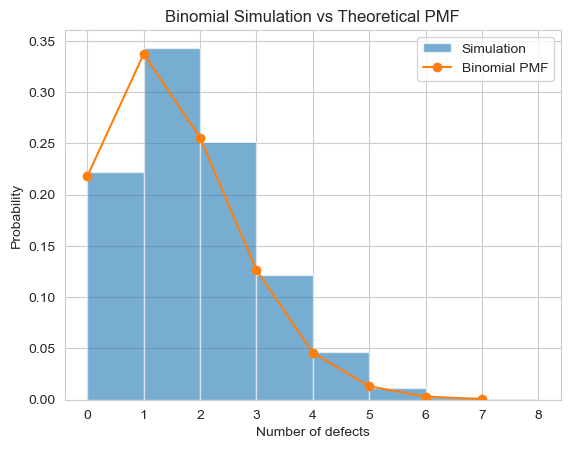

=== Empirical vs Theoretical ===
P(0 defects):      Empirical = 0.2224, Theoretical = 0.2181
P(>=3 defects):    Empirical = 0.1828, Theoretical = 0.1892
Mean defects:      Empirical = 1.4751, Theoretical = 1.5000


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 50          # widgets per batch
p = 0.03        # defect probability
num_batches = 10000

np.random.seed(42)

# 1. Simulate batches
batches = np.random.binomial(n=n, p=p, size=num_batches)

# 2. Histogram (empirical distribution)
counts, bins, _ = plt.hist(
    batches,
    bins=range(0, max(batches)+2),
    density=True,
    alpha=0.6,
    label="Simulation"
)

# 3. Theoretical Binomial PMF
x = np.arange(0, max(batches)+1)
pmf = binom.pmf(x, n, p)

plt.plot(x, pmf, 'o-', label="Binomial PMF")

plt.xlabel("Number of defects")
plt.ylabel("Probability")
plt.title("Binomial Simulation vs Theoretical PMF")
plt.legend()
plt.show()

# 4. Empirical estimates

# P(0 defects)
p0_emp = np.mean(batches == 0)

# P(3 or more defects)
p3_emp = np.mean(batches >= 3)

# Expected value
mean_emp = np.mean(batches)

# 5. Theoretical values

p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
mean_theory = n * p

# Print results
print("=== Empirical vs Theoretical ===")
print(f"P(0 defects):      Empirical = {p0_emp:.4f}, Theoretical = {p0_theory:.4f}")
print(f"P(>=3 defects):    Empirical = {p3_emp:.4f}, Theoretical = {p3_theory:.4f}")
print(f"Mean defects:      Empirical = {mean_emp:.4f}, Theoretical = {mean_theory:.4f}")

The empirical estimates are very close to the theoretical values, with only small differences due to randomness. For example, the probabilities and mean from the simulation closely match the expected binomial results.

While 1,000 batches might give a rough approximation, it would show more variability. Using 10,000 batches provides more stable and accurate estimates, making it preferable for reliable results.